# IMAES - Experiment 6: Fuzzy Logic and Constraint Satisfaction

**Name:** Atharv Gupta   
**Roll Number:** U23AI084  
**College:** Sardar Vallabhbhai National Institute of Technology (SVNIT), Surat  
**Department:** Artificial Intelligence  
**Course:** AI401 - Intelligent Multi-Agent and Expert Systems

## Aim
To implement a simple fuzzy logic system and solve a constraint satisfaction problem using rules and constraints.

## Assignment tasks
1. Build a fuzzy logic system to determine **student performance** from **attendance** and **marks**, and observe how the output changes for different inputs.
2. Build a **timetable constraint satisfaction problem (CSP)** using variables, time-slot domains and constraints, then generate a timetable without violating the constraints.
3. Change some fuzzy rules or constraints and run the program again to observe how the final result changes.

The assignment PDF does not specify exact membership functions, fuzzy rules, subjects, time slots, or timetable constraints. Therefore, the notebook defines a small, explicit example knowledge base and constraints so that every requested task can be executed and checked reproducibly.

## 1. Fuzzy Logic System - Student Performance

### Basic idea
Fuzzy logic allows a value to belong to more than one linguistic category with different degrees. For example, an attendance value of 60% can be partly **Medium** and partly **High**.

Here we use a **Mamdani-style** fuzzy system:

- Inputs: attendance (%) and marks (%)
- Output: performance score (0-100)
- Fuzzification: convert numerical inputs into membership degrees
- Rule evaluation: calculate each rule's firing strength using `min`
- Aggregation: combine all fired output fuzzy sets using `max`
- Defuzzification: use the centroid of the aggregated output

### Input membership functions
For both attendance and marks:
- Low: triangular `(0, 0, 50)`
- Medium: triangular `(25, 60, 95)`
- High: triangular `(50, 100, 100)`

### Output membership functions
- Poor: `(0, 0, 40)`
- Average: `(25, 50, 75)`
- Good: `(50, 70, 90)`
- Excellent: `(70, 100, 100)`

### Fuzzy rule base
| Rule | Attendance | Marks | Performance |
|---|---|---|---|
| R1 | Low | Low | Poor |
| R2 | Low | Medium | Average |
| R3 | Low | High | Average |
| R4 | Medium | Low | Average |
| R5 | Medium | Medium | Good |
| R6 | Medium | High | Excellent |
| R7 | High | Low | Average |
| R8 | High | Medium | Good |
| R9 | High | High | Excellent |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=3, suppress=True)


def triangular(x, a, b, c):
    """Triangular membership function."""
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x)

    # Rising side
    if b != a:
        mask = (x >= a) & (x <= b)
        result[mask] = (x[mask] - a) / (b - a)
    else:
        result[x == a] = 1.0

    # Falling side
    if c != b:
        mask = (x >= b) & (x <= c)
        result[mask] = np.maximum(result[mask], (c - x[mask]) / (c - b))
    else:
        result[x == c] = 1.0

    result[x == b] = 1.0
    return result


FuzzySet = dict

input_sets = {
    'Low': (0, 0, 50),
    'Medium': (25, 60, 95),
    'High': (50, 100, 100),
}

output_sets = {
    'Poor': (0, 0, 40),
    'Average': (25, 50, 75),
    'Good': (50, 70, 90),
    'Excellent': (70, 100, 100),
}

rules = [
    ('Low', 'Low', 'Poor'),
    ('Low', 'Medium', 'Average'),
    ('Low', 'High', 'Average'),
    ('Medium', 'Low', 'Average'),
    ('Medium', 'Medium', 'Good'),
    ('Medium', 'High', 'Excellent'),
    ('High', 'Low', 'Average'),
    ('High', 'Medium', 'Good'),
    ('High', 'High', 'Excellent'),
]


def fuzzify(value, sets):
    """Return membership degree for each linguistic value."""
    result = {}
    for name, params in sets.items():
        result[name] = float(triangular(np.array([value], dtype=float), *params)[0])
    return result


def evaluate_fuzzy(attendance, marks, rule_base=rules, draw=False):
    """Evaluate the Mamdani fuzzy system and return the crisp score and details."""
    attendance = float(attendance)
    marks = float(marks)
    if not (0 <= attendance <= 100 and 0 <= marks <= 100):
        raise ValueError('Attendance and marks must be between 0 and 100.')

    att_mu = fuzzify(attendance, input_sets)
    marks_mu = fuzzify(marks, input_sets)

    universe = np.linspace(0, 100, 1001)
    aggregated = np.zeros_like(universe)
    fired_rules = []

    for idx, (att_label, mark_label, out_label) in enumerate(rule_base, start=1):
        strength = min(att_mu[att_label], marks_mu[mark_label])
        if strength > 0:
            output_mu = triangular(universe, *output_sets[out_label])
            aggregated = np.maximum(aggregated, np.minimum(strength, output_mu))
            fired_rules.append((f'R{idx}', att_label, mark_label, out_label, strength))

    if np.sum(aggregated) == 0:
        score = float('nan')
        performance = 'Undefined'
    else:
        score = float(np.sum(universe * aggregated) / np.sum(aggregated))
        if score < 40:
            performance = 'Poor'
        elif score < 60:
            performance = 'Average'
        elif score < 80:
            performance = 'Good'
        else:
            performance = 'Excellent'

    if draw:
        plt.figure(figsize=(9, 4.8))
        for label, params in output_sets.items():
            plt.plot(universe, triangular(universe, *params), label=label)
        plt.fill_between(universe, aggregated, alpha=0.25, label='Aggregated output')
        if not np.isnan(score):
            plt.axvline(score, linestyle='--', label=f'Centroid = {score:.2f}')
        plt.xlabel('Performance score')
        plt.ylabel('Membership degree')
        plt.title(f'Fuzzy output for attendance={attendance:.0f}%, marks={marks:.0f}%')
        plt.legend()
        plt.grid(alpha=0.25)
        plt.show()

    return {
        'attendance': attendance,
        'marks': marks,
        'attendance_membership': att_mu,
        'marks_membership': marks_mu,
        'fired_rules': fired_rules,
        'score': score,
        'performance': performance,
    }

print('Fuzzy logic system loaded successfully.')

Fuzzy logic system loaded successfully.


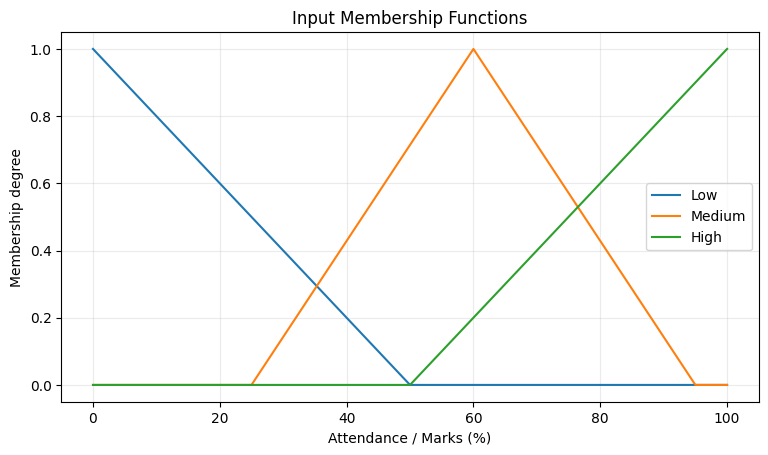

In [2]:
# Visualize the input membership functions
universe = np.linspace(0, 100, 1001)
plt.figure(figsize=(9, 4.8))
for label, params in input_sets.items():
    plt.plot(universe, triangular(universe, *params), label=label)
plt.xlabel('Attendance / Marks (%)')
plt.ylabel('Membership degree')
plt.title('Input Membership Functions')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Exercise 1 - Try different attendance and marks values

The next cell evaluates several combinations. This directly demonstrates the required observation: changing attendance or marks changes the firing strengths of the fuzzy rules and therefore changes the final performance score.

In [3]:
test_cases = [
    (35, 40),
    (50, 55),
    (65, 60),
    (80, 75),
    (90, 90),
]

results = []
for attendance, marks in test_cases:
    r = evaluate_fuzzy(attendance, marks)
    results.append((attendance, marks, r['score'], r['performance']))

print(f"{'Attendance':>10} {'Marks':>8} {'Score':>10} {'Performance':>12}")
print('-' * 45)
for attendance, marks, score, performance in results:
    print(f"{attendance:>10.0f} {marks:>8.0f} {score:>10.2f} {performance:>12}")


Attendance    Marks      Score  Performance
---------------------------------------------
        35       40      46.99      Average
        50       55      71.39         Good
        65       60      72.63         Good
        80       75      76.96         Good
        90       90      84.95    Excellent


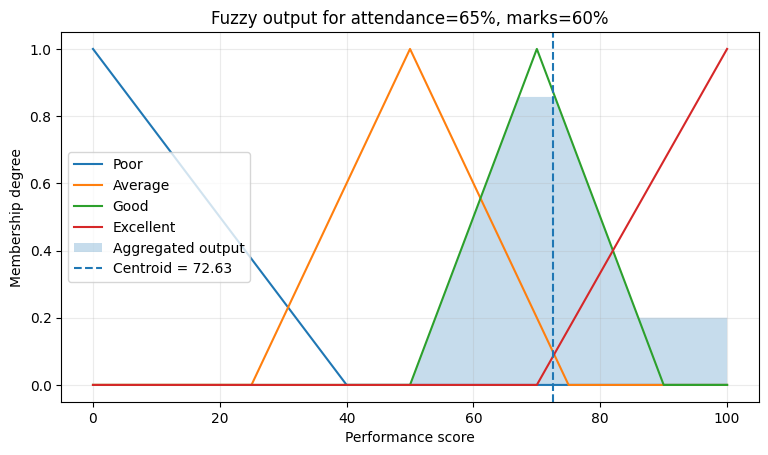

Attendance memberships: {'Low': 0.0, 'Medium': 0.8571428571428571, 'High': 0.3}
Marks memberships: {'Low': 0.0, 'Medium': 1.0, 'High': 0.2}

Fired rules:
R5: Medium AND Medium -> Good, firing strength=0.857
R6: Medium AND High -> Excellent, firing strength=0.200
R8: High AND Medium -> Good, firing strength=0.300
R9: High AND High -> Excellent, firing strength=0.200

Final score = 72.63
Final performance category = Good


In [4]:
# Detailed inspection of one case, including membership values and fired rules
case = evaluate_fuzzy(65, 60, draw=True)

print('Attendance memberships:', case['attendance_membership'])
print('Marks memberships:', case['marks_membership'])
print()
print('Fired rules:')
for rule in case['fired_rules']:
    rule_id, att_label, mark_label, out_label, strength = rule
    print(f"{rule_id}: {att_label} AND {mark_label} -> {out_label}, firing strength={strength:.3f}")
print()
print(f"Final score = {case['score']:.2f}")
print(f"Final performance category = {case['performance']}")

### Observation for Exercise 1

- Very low attendance and marks mainly activate the **Poor/Average** rules.
- When both attendance and marks increase, rules leading to **Good/Excellent** fire more strongly.
- The final score is continuous rather than being restricted to one exact class because multiple fuzzy rules can contribute at the same time.

This is the main difference from a hard threshold system: a student close to a boundary can partially belong to more than one category.

## 2. Constraint Satisfaction Problem - Timetable

A **Constraint Satisfaction Problem (CSP)** is represented by:

- **Variables:** subjects that must be scheduled.
- **Domains:** possible time slots for each subject.
- **Constraints:** conditions that every valid assignment must satisfy.

### Subjects
`DSA`, `DBMS`, `AI`, `NLP`, `AI_Lab`

### Time-slot domain
- Monday 09-10
- Monday 11-12
- Tuesday 09-10
- Tuesday 11-12
- Wednesday 09-10
- Wednesday 11-12
- Thursday 09-10
- Thursday 11-12

### Constraints
1. No two subjects can use the same time slot.
2. `AI` must be scheduled after `DSA`.
3. `NLP` and `DBMS` must be on different days.
4. `AI` and `DBMS` cannot be adjacent periods on the same day.
5. `AI_Lab` must be on Tuesday or Thursday.

We solve the CSP using **backtracking search** with a simple consistency check after every assignment.

In [5]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Slot:
    day: str
    period: int
    label: str

    @property
    def order(self):
        day_order = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3}
        return day_order[self.day] * 2 + (self.period - 1)

    def __str__(self):
        return self.label


slots = [
    Slot('Monday', 1, 'Monday 09-10'),
    Slot('Monday', 2, 'Monday 11-12'),
    Slot('Tuesday', 1, 'Tuesday 09-10'),
    Slot('Tuesday', 2, 'Tuesday 11-12'),
    Slot('Wednesday', 1, 'Wednesday 09-10'),
    Slot('Wednesday', 2, 'Wednesday 11-12'),
    Slot('Thursday', 1, 'Thursday 09-10'),
    Slot('Thursday', 2, 'Thursday 11-12'),
]

variables = ['DSA', 'DBMS', 'AI', 'NLP', 'AI_Lab']

def same_day(a, b):
    return a.day == b.day


def adjacent(a, b):
    return a.day == b.day and abs(a.period - b.period) == 1


def timetable_constraints(assignment, lab_days=('Tuesday', 'Thursday')):
    """Return True when the partial assignment is consistent with all constraints."""
    # 1. All-different for assigned variables.
    assigned_slots = list(assignment.values())
    if len(set(assigned_slots)) != len(assigned_slots):
        return False

    # 5. AI_Lab only on allowed days.
    if 'AI_Lab' in assignment and assignment['AI_Lab'].day not in lab_days:
        return False

    # 2. AI after DSA when both are assigned.
    if 'DSA' in assignment and 'AI' in assignment:
        if assignment['AI'].order <= assignment['DSA'].order:
            return False

    # 3. NLP and DBMS on different days.
    if 'NLP' in assignment and 'DBMS' in assignment:
        if same_day(assignment['NLP'], assignment['DBMS']):
            return False

    # 4. AI and DBMS cannot be adjacent on the same day.
    if 'AI' in assignment and 'DBMS' in assignment:
        if adjacent(assignment['AI'], assignment['DBMS']):
            return False

    return True


def solve_timetable(lab_days=('Tuesday', 'Thursday')):
    """Backtracking CSP solver. Returns one valid timetable or None."""
    domains = {var: list(slots) for var in variables}
    domains['AI_Lab'] = [s for s in slots if s.day in lab_days]

    def backtrack(assignment):
        if len(assignment) == len(variables):
            return assignment.copy()

        # Minimum Remaining Values among unassigned variables.
        unassigned = [v for v in variables if v not in assignment]
        unassigned.sort(key=lambda v: sum(timetable_constraints({**assignment, v: s}, lab_days) for s in domains[v]))
        var = unassigned[0]

        for value in domains[var]:
            candidate = {**assignment, var: value}
            if timetable_constraints(candidate, lab_days):
                solution = backtrack(candidate)
                if solution is not None:
                    return solution
        return None

    return backtrack({})


def validate_timetable(solution, lab_days=('Tuesday', 'Thursday')):
    if solution is None or set(solution) != set(variables):
        return False
    return timetable_constraints(solution, lab_days)


def print_timetable(solution, title='Timetable'):
    print(title)
    print('-' * len(title))
    for var in variables:
        print(f'{var:8s} -> {solution[var]}')


In [6]:
solution = solve_timetable()

assert solution is not None, 'No timetable solution was found.'
assert validate_timetable(solution), 'Generated timetable violates a constraint.'

print_timetable(solution, 'Generated timetable')
print()
print('Constraint check: PASSED - no rule is violated.')

Generated timetable
-------------------
DSA      -> Monday 09-10
DBMS     -> Monday 11-12
AI       -> Tuesday 11-12
NLP      -> Wednesday 09-10
AI_Lab   -> Tuesday 09-10

Constraint check: PASSED - no rule is violated.


### Observation for Exercise 2

The timetable is generated by assigning one slot at a time and backtracking whenever a partial assignment violates a constraint. The final schedule is accepted only after all variables are assigned and every constraint is satisfied.

The important CSP idea is that **constraints prune invalid choices early**, reducing unnecessary search.

## 3. Change the Rules / Constraints and Run Again

The assignment asks us to modify some rules or constraints and observe the effect. Here we change **both** parts:

### Fuzzy-rule change
Original rule:
- `Medium attendance AND High marks -> Excellent`

Modified rule:
- `Medium attendance AND High marks -> Good`

This makes the system more conservative for students whose marks are high but attendance is only in the medium range.

### Timetable-constraint change
Original laboratory constraint:
- `AI_Lab` may be on **Tuesday or Thursday**.

Modified laboratory constraint:
- `AI_Lab` must be on **Thursday**.

The modified CSP is solved again from scratch.

Fuzzy rule change:
Original: Medium + High -> Excellent | score = 84.95
Changed : Medium + High -> Good      | score = 73.96
Score change = -10.99


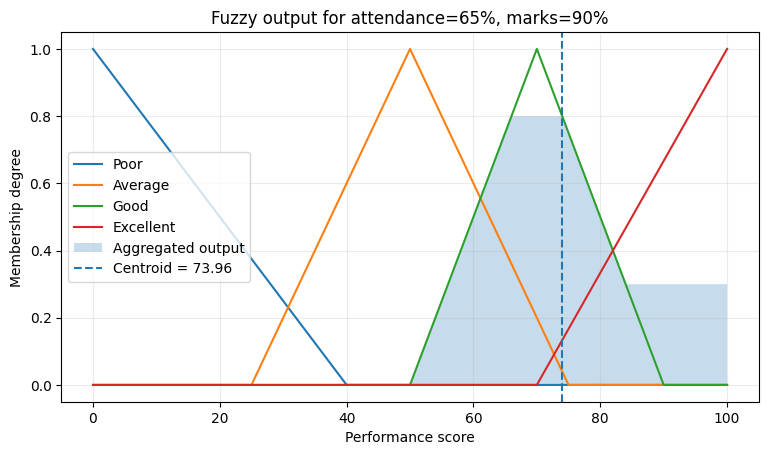

In [7]:
# ----- Fuzzy rule modification -----
modified_rules = [
    ('Low', 'Low', 'Poor'),
    ('Low', 'Medium', 'Average'),
    ('Low', 'High', 'Average'),
    ('Medium', 'Low', 'Average'),
    ('Medium', 'Medium', 'Good'),
    ('Medium', 'High', 'Good'),      # changed from Excellent -> Good
    ('High', 'Low', 'Average'),
    ('High', 'Medium', 'Good'),
    ('High', 'High', 'Excellent'),
]

before = evaluate_fuzzy(65, 90, rule_base=rules)
after = evaluate_fuzzy(65, 90, rule_base=modified_rules)

print('Fuzzy rule change:')
print(f"Original: Medium + High -> Excellent | score = {before['score']:.2f}")
print(f"Changed : Medium + High -> Good      | score = {after['score']:.2f}")
print(f"Score change = {after['score'] - before['score']:.2f}")

after2 = evaluate_fuzzy(65, 90, rule_base=modified_rules, draw=True)


In [8]:
# ----- Timetable constraint modification -----
modified_solution = solve_timetable(lab_days=('Thursday',))

assert modified_solution is not None, 'Modified CSP unexpectedly has no solution.'
assert validate_timetable(modified_solution, lab_days=('Thursday',)), 'Modified timetable violates a constraint.'

print_timetable(solution, 'Original timetable')
print()
print_timetable(modified_solution, 'Modified timetable (AI_Lab only on Thursday)')
print()
print('Modified constraint check: PASSED')


Original timetable
------------------
DSA      -> Monday 09-10
DBMS     -> Monday 11-12
AI       -> Tuesday 11-12
NLP      -> Wednesday 09-10
AI_Lab   -> Tuesday 09-10

Modified timetable (AI_Lab only on Thursday)
--------------------------------------------
DSA      -> Monday 09-10
DBMS     -> Monday 11-12
AI       -> Tuesday 09-10
NLP      -> Tuesday 11-12
AI_Lab   -> Thursday 09-10

Modified constraint check: PASSED


### Observation for Exercise 3

The fuzzy-rule modification changes the contribution of the rule for **medium attendance + high marks**, so the resulting performance score becomes lower for that case.

The timetable modification removes all Tuesday choices for `AI_Lab`. The solver therefore searches a smaller domain for that variable and can produce a different valid timetable while still satisfying the remaining constraints.

This demonstrates an important point: in both systems, the final result depends directly on the knowledge encoded in the rules/constraints.

## Final Verification

The following checks confirm that all assignment tasks were implemented:

- Fuzzy logic system accepts attendance and marks as inputs.
- Different input values produce different fuzzy performance outputs.
- Membership degrees, fired rules and defuzzified score are displayed.
- A timetable CSP contains variables, domains and explicit constraints.
- Backtracking generates a timetable satisfying all constraints.
- Fuzzy rules are modified and the system is run again.
- A timetable constraint is modified and the CSP is solved again.
- Assertions verify that both original and modified timetables are valid.


In [ ]:
# Final automated checks

# Fuzzy system basic correctness
fuzzy_check = evaluate_fuzzy(80, 85)
assert 0 <= fuzzy_check['score'] <= 100
assert fuzzy_check['performance'] in {'Poor', 'Average', 'Good', 'Excellent'}

# Original CSP
original = solve_timetable()
assert validate_timetable(original)

# Modified CSP
changed = solve_timetable(lab_days=('Thursday',))
assert validate_timetable(changed, lab_days=('Thursday',))
assert changed['AI_Lab'].day == 'Thursday'

print('✓ Fuzzy student-performance system verified')
print('✓ Exercise 1 input/output observation verified')
print('✓ Original timetable CSP verified')
print('✓ Exercise 2 no-violation constraint check verified')
print('✓ Modified fuzzy-rule experiment verified')
print('✓ Modified timetable-constraint experiment verified')
print()
print('ALL EXPERIMENT 6 TASKS PASSED.')

✓ Fuzzy student-performance system verified
✓ Exercise 1 input/output observation verified
✓ Original timetable CSP verified
✓ Exercise 2 no-violation constraint check verified
✓ Modified fuzzy-rule experiment verified
✓ Modified timetable-constraint experiment verified

ALL EXPERIMENT 6 TASKS PASSED.


: 

## Conclusion

In this experiment, two AI techniques were implemented.

**Fuzzy logic** was used to map attendance and marks to a student-performance score. Because the inputs have degrees of membership, the result changes smoothly as the values change.

**Constraint satisfaction** was used to construct a timetable. The backtracking solver assigns subjects to time slots while rejecting partial assignments that violate the constraints.

Changing the fuzzy rule base changes the performance output, while changing the timetable constraints changes the space of valid schedules and can lead to a different solution.

The complete implementation therefore covers all three exercises in the assignment.